# ⏱️ Day 3 REVISED — Full-City Temporal Profiling + Patrol Scheduler + GenAI
**ParkSentinel | Gridlock Hackathon 2.0**

**Key changes from previous Day 3:**
- Profiles ALL hex zones (not just top 20) — every station visible in dashboard
- Zone labels = `"Station — Junction"` (unique, no duplicates)
- No-junction zones use nearest road from address string
- Surge calculation for Wildcard patrol slot (14-day window, min 20 violations)
- Prophet only on Critical + High tier zones (fast enough, accurate enough)
- Checkpoint saves every 100 zones so a crash doesn't lose work
- AI context includes ALL zones grouped by tier + stratified mission context
- Aggressive time-boost (×3.0) so patrol queue visibly re-sorts by hour

**Stratified Patrol Missions (Scheduler):**
- 🔴 Firefighter  — #1 Critical zone right now
- 🟡 Preventative — Highest Medium/Low zone with upward trend (skip+message if none)
- 🔵 Wildcard     — Highest surge zone (≥20 violations, last 14d vs prior 14d)


## 1. Setup & Load Data

In [1]:
import subprocess, sys

pkgs = ["prophet","google-generativeai","pandas","numpy",
        "matplotlib","seaborn","plotly","tqdm","pyarrow","python-dotenv","h3"]
print("Checking packages...")
for p in pkgs:
    subprocess.run([sys.executable,"-m","pip","install",p,"-q","--break-system-packages"],
                   capture_output=True)
print("✅ Done.")


Checking packages...
✅ Done.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json, ast, os, threading, time, re
from pathlib import Path
from tqdm import tqdm
from dotenv import load_dotenv
import logging

logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)

load_dotenv()
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize":(13,5), "axes.spines.top":False,
    "axes.spines.right":False, "axes.titlesize":13,
    "axes.titleweight":"bold", "figure.dpi":120,
})
sns.set_palette("husl")

ROOT      = Path(r"D:\Coding Stuff\grid2")
PROCESSED = ROOT / "data" / "processed"
MODELS    = ROOT / "models"
NOTEBOOKS = ROOT / "notebooks"

CLEAN_PQ   = PROCESSED / "violations_clean_day1.parquet"
HEX_PQ     = PROCESSED / "h3_priority_scores.parquet"
CLUSTER_PQ = PROCESSED / "cluster_profiles.parquet"
MAPPING_PQ = PROCESSED / "violations_with_clusters.parquet"

print("Loading data...")
df      = pd.read_parquet(CLEAN_PQ)
hex_df  = pd.read_parquet(HEX_PQ)
cluster = pd.read_parquet(CLUSTER_PQ)

def to_list(v):
    if isinstance(v, list): return v
    try:    return ast.literal_eval(str(v))
    except: return []

df["violation_list"]    = df["violation_list"].apply(to_list)
df["offence_code_list"] = df["offence_code_list"].apply(to_list)

print(f"✅ Violations  : {len(df):,}")
print(f"✅ Hex cells   : {len(hex_df):,}")
print(f"✅ Clusters    : {len(cluster):,}")
print(f"✅ Unique tiers: {hex_df['final_priority_tier'].value_counts().to_dict()}")


Loading data...
✅ Violations  : 298,282
✅ Hex cells   : 764
✅ Clusters    : 73
✅ Unique tiers: {'Very Low': 570, 'Medium': 139, 'High': 50, 'Low': 3, 'Critical': 2}


In [3]:
# Merge h3_id onto violation records (same fix as your working Day 3)
h3_mapping = pd.read_parquet(MAPPING_PQ)
df = df.merge(h3_mapping[["id","h3_id"]], on="id", how="left")
df = df.merge(
    hex_df[["h3_id","ensemble_score","final_priority_tier","priority_score",
             "police_station","top_junction","violation_count",
             "near_junction_ratio","peak_hour_ratio","severity_mean",
             "lat","lon"]],
    on="h3_id", how="left"
)

# Rename any _x columns from merge collision
for col in ["police_station","violation_count"]:
    if f"{col}_x" in df.columns:
        df.rename(columns={f"{col}_x": col}, inplace=True)
    if f"{col}_y" in df.columns:
        df.drop(columns=[f"{col}_y"], inplace=True)

print(f"✅ Merged. df shape: {df.shape}")
print(f"   Unique h3 cells in df: {df['h3_id'].nunique():,}")


✅ Merged. df shape: (298282, 44)
   Unique h3 cells in df: 764


## 2. Zone Label Generation — `"Station — Junction/Road"`

Every zone gets a unique human-readable label:
- If zone has a named junction → `"Upparpet — Elite Junction"`
- If no junction → extract nearest road from address string → `"Upparpet — 5th Main Road"`
- Still clashes (rare) → append short h3 suffix → `"Upparpet — Gandhi Nagar (8C2A)"`

This eliminates all duplicate dropdown entries in the dashboard.


In [4]:
# Road extraction from address string (pure dataset, no external data)
ROAD_KEYWORDS = [
    "MAIN ROAD","OUTER RING ROAD","RING ROAD","HIGHWAY",
    "CROSS ROAD","ROAD","AVENUE","STREET","NAGAR","LAYOUT","COLONY"
]

def extract_road_from_address(loc_str):
    """Extract the most specific road/area name from the location string."""
    if pd.isna(loc_str) or str(loc_str).strip() == "": return None
    loc = str(loc_str).upper()
    # Try to find a road reference — take the first comma-separated segment
    # that contains a road keyword
    segments = [s.strip() for s in str(loc_str).split(",")]
    for seg in segments[:4]:  # only look at first 4 parts of address
        seg_up = seg.upper()
        for kw in ROAD_KEYWORDS:
            if kw in seg_up:
                # Clean it up: title case, max 25 chars
                clean = seg.strip().title()[:25]
                return clean
    # Fallback: return first meaningful segment (not a PIN or country)
    for seg in segments[:3]:
        seg = seg.strip()
        if seg and not seg.upper().startswith("PIN") and len(seg) > 3:
            return seg.title()[:25]
    return None


def build_zone_label(station, junction, h3_id, address_sample):
    """Build a unique Zone Label for display."""
    station_clean = str(station).title() if station else "Unknown"

    # Junction takes priority
    if junction and str(junction).upper() not in ("NO JUNCTION", "NAN", "NONE", ""):
        # Strip "BTP### - " prefix if present
        junc_clean = re.sub(r'^BTP\d+\s*-\s*', '', str(junction)).strip().title()[:30]
        return f"{station_clean} — {junc_clean}"

    # Try to extract road from address
    road = extract_road_from_address(address_sample)
    if road:
        return f"{station_clean} — {road}"

    # Last resort: h3 suffix
    return f"{station_clean} — Zone {h3_id[:4].upper()}"


# Build label for each hex cell using a sample address from that zone
print("Building zone labels for all hex cells...")
address_sample_map = (
    df.dropna(subset=["h3_id","location"])
    .groupby("h3_id")["location"]
    .first()
    .to_dict()
)

hex_df["zone_label_raw"] = hex_df.apply(
    lambda r: build_zone_label(
        r["police_station"],
        r["top_junction"],
        r["h3_id"],
        address_sample_map.get(r["h3_id"], "")
    ), axis=1
)

# Deduplicate: if same raw label appears more than once, append h3 suffix
label_counts = hex_df["zone_label_raw"].value_counts()
duplicated_labels = set(label_counts[label_counts > 1].index)

def deduplicate_label(row):
    if row["zone_label_raw"] in duplicated_labels:
        return f"{row['zone_label_raw']} ({row['h3_id'][:4].upper()})"
    return row["zone_label_raw"]

hex_df["zone_label"] = hex_df.apply(deduplicate_label, axis=1)

print(f"✅ Zone labels built for {len(hex_df):,} hex cells")
print(f"   Duplicate labels resolved: {len(duplicated_labels)}")
print(f"\nSample labels:")
print(hex_df.nlargest(10,"ensemble_score")[["police_station","top_junction","zone_label"]].to_string(index=False))


Building zone labels for all hex cells...
✅ Zone labels built for 764 hex cells
   Duplicate labels resolved: 123

Sample labels:
police_station                        top_junction                                  zone_label
      UPPARPET             BTP040 - ELITE JUNCTION                   Upparpet — Elite Junction
  SHIVAJINAGAR      BTP051 - SAFINA PLAZA JUNCTION Shivajinagar — Safina Plaza Junction (8861)
      UPPARPET     BTP044 - SAGAR THEATRE JUNCTION    Upparpet — Sagar Theatre Junction (8860)
   CITY MARKET         BTP082 - KR MARKET JUNCTION            City Market — Kr Market Junction
      UPPARPET     BTP044 - SAGAR THEATRE JUNCTION    Upparpet — Sagar Theatre Junction (8860)
  MALLESHWARAM       BTP027 - MODI BRIDGE JUNCTION         Malleshwaram — Modi Bridge Junction
 HALASURU GATE  BTP080 - NR ROAD, SP ROAD JUNCTION   Halasuru Gate — Nr Road, Sp Road Junction
  SHIVAJINAGAR    BTP211 - CENTRAL STREET JUNCTION      Shivajinagar — Central Street Junction
       HALASUR 

## 3. Surge Calculation (for Wildcard Patrol Slot)

For each zone, compare violations in the **last 14 days of the dataset**
vs the **14 days before that**. Zones with ≥20 violations in the recent
window and a surge >10% qualify as Wildcard candidates.

Dataset end date is used as reference — not today's date.


In [5]:
# Find dataset date boundaries
df["date_parsed"] = pd.to_datetime(df["date"], errors="coerce")
dataset_end   = df["date_parsed"].max()
recent_start  = dataset_end - pd.Timedelta(days=14)
prior_start   = dataset_end - pd.Timedelta(days=28)
prior_end     = recent_start

print(f"Dataset end    : {dataset_end.date()}")
print(f"Recent window  : {recent_start.date()} → {dataset_end.date()}")
print(f"Prior window   : {prior_start.date()} → {prior_end.date()}")

df_recent = df[df["date_parsed"] >= recent_start]
df_prior  = df[(df["date_parsed"] >= prior_start) & (df["date_parsed"] < recent_start)]

recent_counts = df_recent.groupby("h3_id")["id"].count().rename("recent_count")
prior_counts  = df_prior.groupby("h3_id")["id"].count().rename("prior_count")

surge_df = pd.DataFrame({"recent_count": recent_counts, "prior_count": prior_counts}).fillna(0)
surge_df["surge_delta"] = surge_df["recent_count"] - surge_df["prior_count"]
surge_df["surge_pct"]   = (
    (surge_df["surge_delta"] / surge_df["prior_count"].replace(0, 1)) * 100
).round(1)

# Merge back to hex_df
hex_df = hex_df.merge(surge_df.reset_index(), on="h3_id", how="left")
hex_df[["recent_count","prior_count","surge_delta","surge_pct"]] = (
    hex_df[["recent_count","prior_count","surge_delta","surge_pct"]].fillna(0)
)

# Wildcard eligible: ≥20 recent violations AND surge > 10%
hex_df["wildcard_eligible"] = (
    (hex_df["recent_count"] >= 20) & (hex_df["surge_pct"] > 10)
).astype(int)

print(f"\n✅ Surge calculated for {len(surge_df):,} zones")
print(f"   Wildcard eligible zones: {hex_df['wildcard_eligible'].sum():,}")
print(f"\nTop 5 surge zones:")
print(hex_df[hex_df["wildcard_eligible"]==1]
      .nlargest(5,"surge_pct")
      [["zone_label","recent_count","prior_count","surge_pct","ensemble_score"]]
      .to_string(index=False))


Dataset end    : 2024-04-08
Recent window  : 2024-03-25 → 2024-04-08
Prior window   : 2024-03-11 → 2024-03-25

✅ Surge calculated for 551 zones
   Wildcard eligible zones: 117

Top 5 surge zones:
                            zone_label  recent_count  prior_count  surge_pct  ensemble_score
             Hennuru — Doddagubbi Road          59.0          1.0     5800.0        3.799169
 Mahadevapura — Whitefield Road (8861)          49.0          0.0     4900.0        1.750702
    J.P. Nagar — Bileka Halli Junction          46.0          1.0     4500.0        7.580997
        Whitefield — Nallurahalli Road          39.0          0.0     3900.0       10.285519
Hennuru — Thanisandra Main Road (8861)          33.0          0.0     3300.0        4.788325


## 4. Build Temporal Profiles for ALL Zones

This is the core fix. We iterate over every hex cell, not just top 20.
Checkpoint saves every 100 zones to `processed/zone_profiles_checkpoint.parquet`
so a crash doesn't lose your work.

Estimated time: 3–8 minutes for ~764 zones.


In [6]:
CHECKPOINT_PATH = PROCESSED / "zone_profiles_checkpoint.parquet"
CHECKPOINT_EVERY = 100

all_h3_ids = hex_df["h3_id"].tolist()

# Check if checkpoint exists — resume from it
if CHECKPOINT_PATH.exists():
    chk = pd.read_parquet(CHECKPOINT_PATH)
    done_ids = set(chk["h3_id"].tolist())
    print(f"♻️  Resuming from checkpoint: {len(done_ids)} zones already done")
    zone_profiles = chk.to_dict("records")
else:
    done_ids = set()
    zone_profiles = []

remaining_ids = [h for h in all_h3_ids if h not in done_ids]
print(f"Profiling {len(remaining_ids):,} remaining zones (of {len(all_h3_ids):,} total)...")
print("Progress saved every 100 zones.")
print()

for idx, h3_id in enumerate(tqdm(remaining_ids, desc="Zone profiles")):
    zone_df = df[df["h3_id"] == h3_id].copy()
    if len(zone_df) == 0:
        continue

    row_hex = hex_df[hex_df["h3_id"] == h3_id]
    rh = row_hex.iloc[0] if len(row_hex) > 0 else {}

    # Hourly distribution
    hour_counts = zone_df["hour"].value_counts().sort_index()
    peak_hour   = int(hour_counts.idxmax()) if len(hour_counts) > 0 else 8

    # Best 2-hour morning window (6–12)
    morning = hour_counts[hour_counts.index.isin(range(6, 12))]
    if len(morning) >= 2:
        best_morning_start = int(morning.rolling(2).sum().idxmax()) - 1
    else:
        best_morning_start = 8

    # Best 2-hour evening window (14–22)
    evening = hour_counts[hour_counts.index.isin(range(14, 23))]
    if len(evening) >= 2:
        best_evening_start = int(evening.rolling(2).sum().idxmax()) - 1
    else:
        best_evening_start = 17

    day_counts = zone_df["day_name"].value_counts()
    peak_day   = day_counts.idxmax() if len(day_counts) > 0 else "Monday"
    wknd_ratio = float(zone_df["is_weekend"].mean())

    all_v  = [v for lst in zone_df["violation_list"] for v in lst]
    top_v  = pd.Series(all_v).value_counts().head(3).index.tolist() if all_v else []
    top_veh = zone_df["vehicle_type"].value_counts().head(2).index.tolist()

    # Trend: last 14 days vs prior 14 days
    recent_c = float(rh.get("recent_count", 0))
    prior_c  = float(rh.get("prior_count", 0))
    surge_p  = float(rh.get("surge_pct", 0))
    if surge_p > 10 and recent_c >= 20:
        trend = "increasing"
    elif surge_p < -10:
        trend = "decreasing"
    else:
        trend = "stable"

    zone_profiles.append({
        "h3_id"              : h3_id,
        "zone_label"         : str(rh.get("zone_label", h3_id[:8])),
        "ensemble_score"     : float(rh.get("ensemble_score", 0)),
        "priority_tier"      : str(rh.get("final_priority_tier", "Very Low")),
        "police_station"     : str(rh.get("police_station", "Unknown")),
        "top_junction"       : str(rh.get("top_junction", "No Junction")),
        "violation_count"    : int(rh.get("violation_count", 0)),
        "lat"                : float(rh.get("lat", 12.97)),
        "lon"                : float(rh.get("lon", 77.59)),
        "peak_hour"          : peak_hour,
        "best_morning_start" : best_morning_start,
        "best_evening_start" : best_evening_start,
        "peak_day"           : peak_day,
        "weekend_ratio"      : round(wknd_ratio, 3),
        "top_violations"     : json.dumps(top_v),
        "top_vehicles"       : json.dumps(top_veh),
        "hourly_counts"      : json.dumps(hour_counts.to_dict()),
        "daily_counts"       : json.dumps(day_counts.to_dict()),
        "severity_mean"      : float(rh.get("severity_mean", 0)),
        "near_junction_ratio": float(rh.get("near_junction_ratio", 0)),
        "peak_hour_ratio"    : float(rh.get("peak_hour_ratio", 0)),
        "recent_count"       : recent_c,
        "prior_count"        : prior_c,
        "surge_pct"          : surge_p,
        "wildcard_eligible"  : int(rh.get("wildcard_eligible", 0)),
        "trend"              : trend,
    })

    # Checkpoint every N zones
    if (idx + 1) % CHECKPOINT_EVERY == 0:
        chk_df = pd.DataFrame(zone_profiles)
        chk_df.to_parquet(CHECKPOINT_PATH, index=False)
        print(f"  💾 Checkpoint saved ({len(zone_profiles)} zones done)")

zone_profile_df = pd.DataFrame(zone_profiles)

# Final checkpoint save
zone_profile_df.to_parquet(CHECKPOINT_PATH, index=False)

print(f"\n✅ ALL ZONES PROFILED: {len(zone_profile_df):,}")
print(f"\nTier breakdown:")
print(zone_profile_df["priority_tier"].value_counts().to_string())
print(f"\nTrend breakdown:")
print(zone_profile_df["trend"].value_counts().to_string())


Profiling 764 remaining zones (of 764 total)...
Progress saved every 100 zones.



Zone profiles:  13%|█▎        | 103/764 [00:03<00:27, 24.00it/s]

  💾 Checkpoint saved (100 zones done)


Zone profiles:  26%|██▋       | 201/764 [00:06<00:28, 19.43it/s]

  💾 Checkpoint saved (200 zones done)


...

  💾 Checkpoint saved (600 zones done)


Zone profiles:  92%|█████████▏| 704/764 [00:27<00:01, 30.49it/s]

  💾 Checkpoint saved (700 zones done)


Zone profiles: 100%|██████████| 764/764 [00:28<00:00, 26.41it/s]


✅ ALL ZONES PROFILED: 764

Tier breakdown:
priority_tier
Very Low    570
Medium      139
High         50
Low           3
Critical      2

Trend breakdown:
trend
stable        421
decreasing    226
increasing    117


## 5. Temporal EDA — All Zones

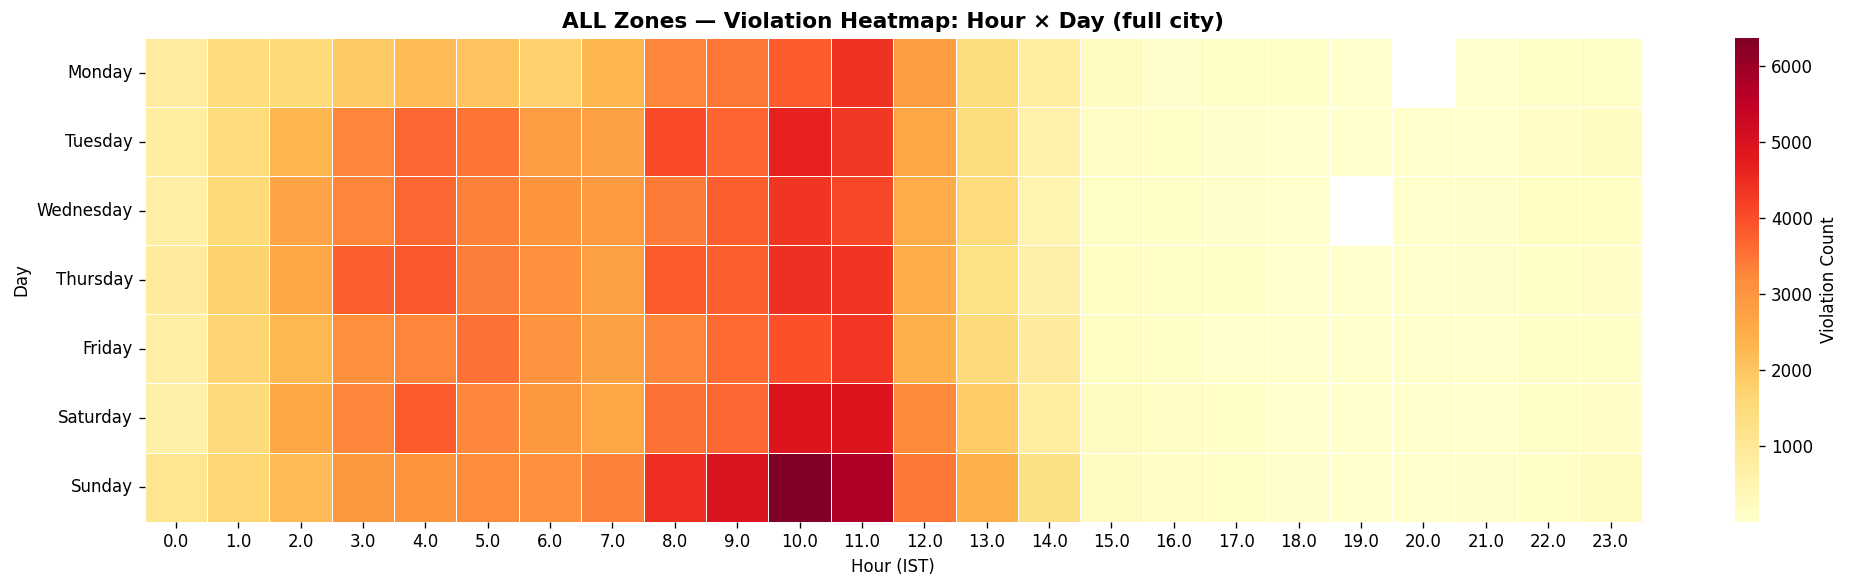

→ This now represents the entire Bengaluru dataset.


In [7]:
# Hour × day heatmap for ALL violations (not just top 20)
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
pivot = df.pivot_table(index="day_name", columns="hour", values="id", aggfunc="count").reindex(day_order)

fig, ax = plt.subplots(figsize=(17,5))
sns.heatmap(pivot, cmap="YlOrRd", ax=ax, linewidths=0.3, cbar_kws={"label":"Violation Count"})
ax.set_title("ALL Zones — Violation Heatmap: Hour × Day (full city)")
ax.set_xlabel("Hour (IST)"); ax.set_ylabel("Day")
plt.tight_layout()
plt.savefig(PROCESSED/"temporal_01_heatmap_allzones.png", bbox_inches="tight")
plt.show()
print("→ This now represents the entire Bengaluru dataset.")


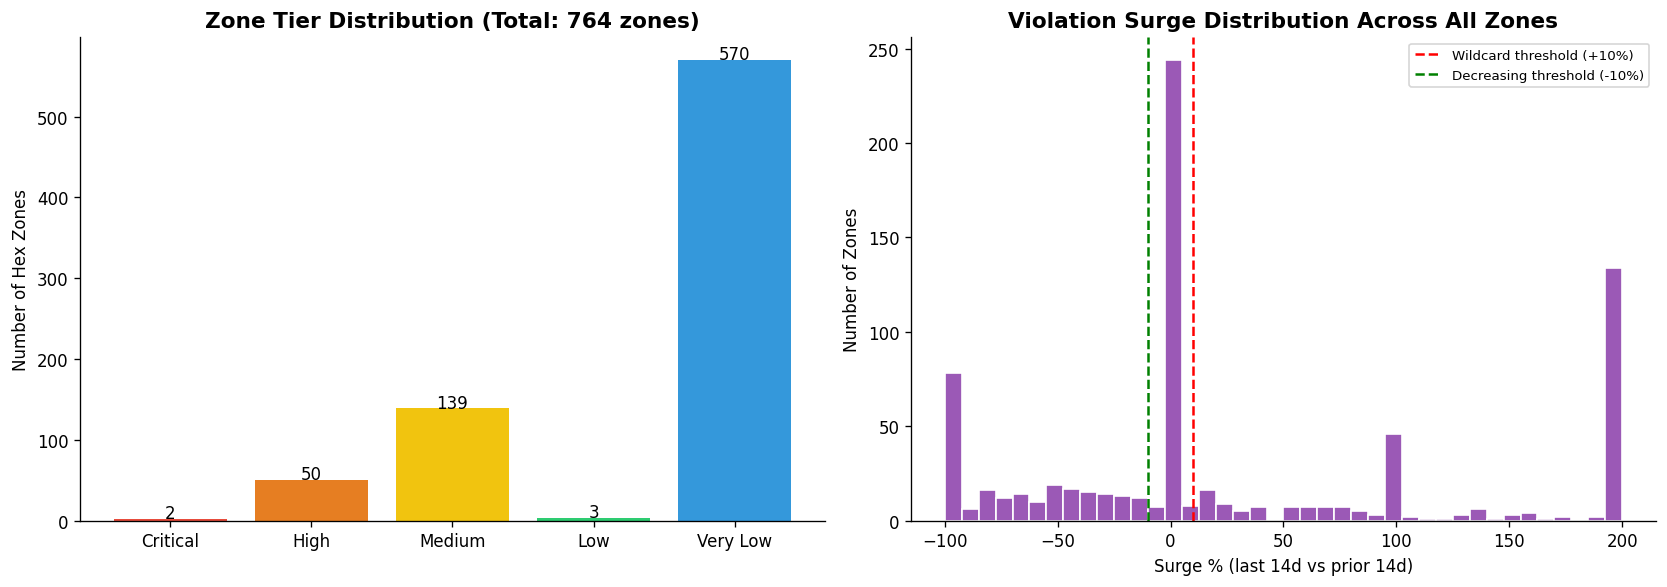

In [8]:
# Tier distribution chart
tier_order = ["Critical","High","Medium","Low","Very Low"]
tier_colors = {"Critical":"#e74c3c","High":"#e67e22","Medium":"#f1c40f",
               "Low":"#2ecc71","Very Low":"#3498db"}
tier_counts = zone_profile_df["priority_tier"].value_counts().reindex(tier_order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].bar(tier_counts.index, tier_counts.values,
            color=[tier_colors[t] for t in tier_counts.index])
axes[0].set_ylabel("Number of Hex Zones")
axes[0].set_title(f"Zone Tier Distribution (Total: {len(zone_profile_df):,} zones)")
for i,(t,v) in enumerate(zip(tier_counts.index, tier_counts.values)):
    axes[0].text(i, v+1, str(int(v)), ha="center", fontsize=10)

# Surge distribution
axes[1].hist(zone_profile_df["surge_pct"].clip(-100,200), bins=40,
             color="#9b59b6", edgecolor="white")
axes[1].axvline(10, color="red", ls="--", lw=1.5, label="Wildcard threshold (+10%)")
axes[1].axvline(-10, color="green", ls="--", lw=1.5, label="Decreasing threshold (-10%)")
axes[1].set_xlabel("Surge % (last 14d vs prior 14d)")
axes[1].set_ylabel("Number of Zones")
axes[1].set_title("Violation Surge Distribution Across All Zones")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(PROCESSED/"temporal_02_tier_surge_dist.png", bbox_inches="tight")
plt.show()


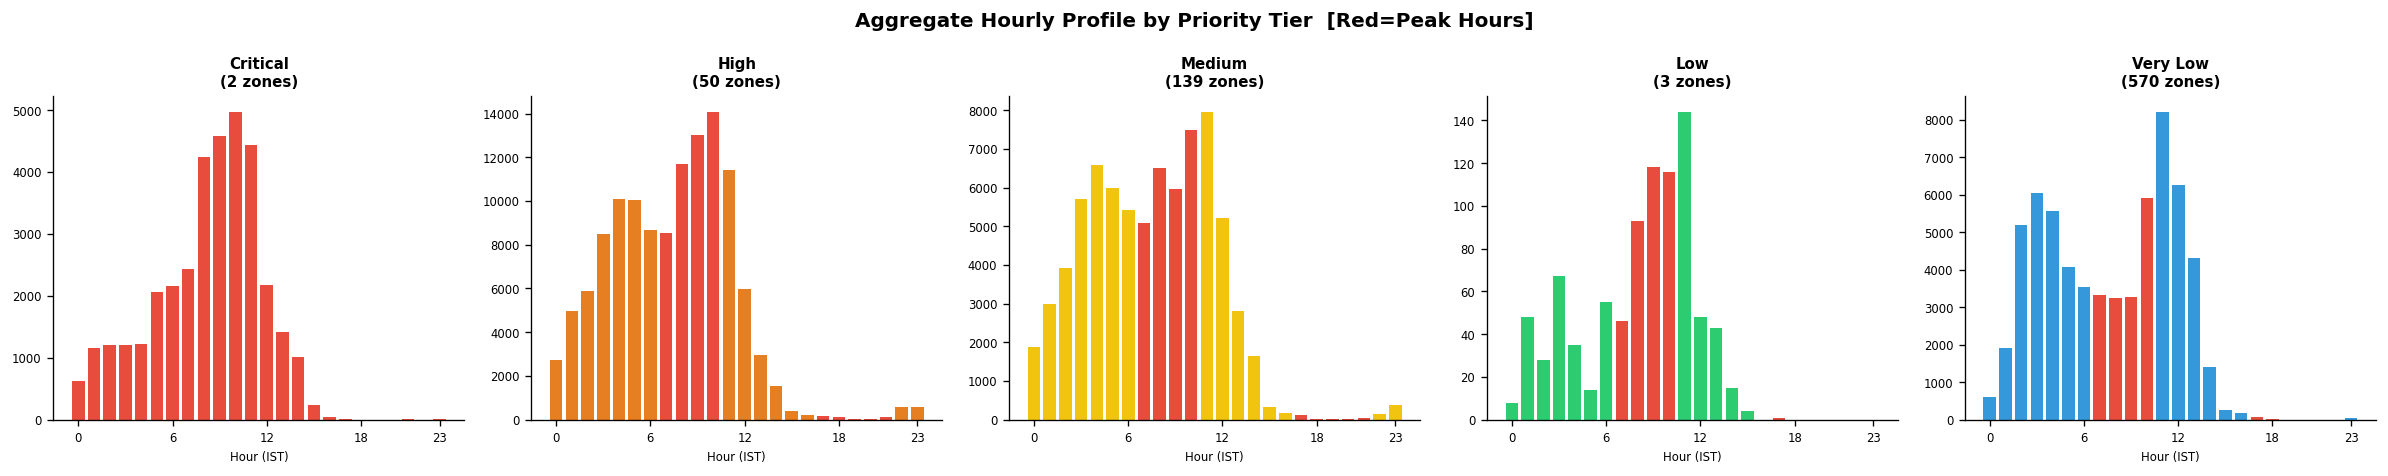

→ Each subplot shows the aggregate violation pattern for that tier.


In [10]:
# Per-tier hourly profile (aggregate)
fig, axes = plt.subplots(1, len(tier_order), figsize=(20, 4))
for ax, tier in zip(axes, tier_order):
    tier_zones = zone_profile_df[zone_profile_df["priority_tier"] == tier]
    if len(tier_zones) == 0:
        ax.set_title(tier); continue

    # Aggregate hourly counts across all zones in this tier
    all_hours = {}
    for _, row in tier_zones.iterrows():
        hc = json.loads(row["hourly_counts"]) if isinstance(row["hourly_counts"], str) else row["hourly_counts"]
        for h, cnt in hc.items():
            # FIX: Safely convert floating-point strings like "0.0" into integers
            hour_key = int(float(h))
            all_hours[hour_key] = all_hours.get(hour_key, 0) + cnt

    hours  = list(range(24))
    counts = [all_hours.get(h, 0) for h in hours]
    colors = ["#e74c3c" if h in list(range(7,11))+list(range(17,22)) else tier_colors.get(tier,"#3498db")
              for h in hours]
    ax.bar(hours, counts, color=colors, width=0.8)
    ax.set_title(f"{tier}\n({len(tier_zones)} zones)", fontsize=9, fontweight="bold")
    ax.set_xticks([0,6,12,18,23]); ax.tick_params(labelsize=7)
    ax.set_xlabel("Hour (IST)", fontsize=7)

plt.suptitle("Aggregate Hourly Profile by Priority Tier  [Red=Peak Hours]",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(PROCESSED/"temporal_03_tier_hourly_profiles.png", bbox_inches="tight", dpi=130)
plt.show()
print("→ Each subplot shows the aggregate violation pattern for that tier.")

## 6. Prophet Forecasting — Critical + High Tier Only

Hybrid approach: full statistical forecasting only where it matters most.
Mid/Low/Very Low zones get trend direction from the surge calculation (Section 3),
which is cheaper and still informative.


In [11]:
from prophet import Prophet
import joblib

# Critical + High zones only
forecast_ids = hex_df[
    hex_df["final_priority_tier"].isin(["Critical","High"])
]["h3_id"].tolist()

print(f"Running Prophet on {len(forecast_ids)} Critical + High zones...")
print("(~10-20s per zone)")
print()

forecast_results = {}
PROPHET_CHECKPOINT = PROCESSED / "prophet_forecasts.parquet"
prophet_rows = []

for h3_id in forecast_ids:
    zone_df = df[df["h3_id"] == h3_id].copy()
    station = hex_df.loc[hex_df["h3_id"]==h3_id, "police_station"].values
    label   = hex_df.loc[hex_df["h3_id"]==h3_id, "zone_label"].values
    station = station[0] if len(station) > 0 else "Unknown"
    label   = label[0]   if len(label)   > 0 else station

    daily = (zone_df.groupby("date")
                    .agg(y=("id","count"))
                    .reset_index()
                    .rename(columns={"date":"ds"}))
    daily["ds"] = pd.to_datetime(daily["ds"])
    daily = daily.sort_values("ds").reset_index(drop=True)

    if len(daily) < 10:
        print(f"  ⚠️  Skipping {label} — only {len(daily)} days")
        continue

    stop_event = threading.Event()
    def _spinner(stop, name):
        start = time.time()
        while not stop.is_set():
            time.sleep(0.5)
            if not stop.is_set():
                print(f"\r  ⏳ Prophet: {name}... ({time.time()-start:.0f}s)", end="")
    t = threading.Thread(target=_spinner, args=(stop_event, label[:30]))
    t.start()

    try:
        mp = Prophet(
            yearly_seasonality=False,
            weekly_seasonality=True,
            daily_seasonality=False,
            interval_width=0.8,
            changepoint_prior_scale=0.05,
        )
        mp.fit(daily)
        future   = mp.make_future_dataframe(periods=30)
        forecast = mp.predict(future)
    finally:
        stop_event.set(); t.join()
        print(f"\r  ✅ {label[:35]:<35s}", end="\n")

    # Trend from last 2 weeks of historical data
    recent_avg  = daily.tail(14)["y"].mean()
    earlier_avg = daily.iloc[-28:-14]["y"].mean() if len(daily)>=28 else daily.head(14)["y"].mean()
    delta       = recent_avg - earlier_avg
    if   delta > earlier_avg * 0.10: prophet_trend = "increasing"
    elif delta < -earlier_avg * 0.10: prophet_trend = "decreasing"
    else:                             prophet_trend = "stable"

    # Next 7 days average prediction
    next7_avg = forecast.tail(7)["yhat"].mean()

    forecast_results[h3_id] = {
        "h3_id": h3_id, "station": station, "label": label,
        "daily": daily,
        "forecast": forecast[["ds","yhat","yhat_lower","yhat_upper"]].copy(),
        "prophet_trend": prophet_trend, "next7_avg": next7_avg,
    }

    # Save row for checkpoint parquet
    for _, frow in forecast[["ds","yhat","yhat_lower","yhat_upper"]].iterrows():
        prophet_rows.append({
            "h3_id": h3_id, "zone_label": label,
            "ds": str(frow["ds"].date()),
            "yhat": round(frow["yhat"],2),
            "yhat_lower": round(frow["yhat_lower"],2),
            "yhat_upper": round(frow["yhat_upper"],2),
        })

    joblib.dump(mp, MODELS/f"prophet_{h3_id[:8]}.joblib")

# Save all forecasts to parquet
if prophet_rows:
    pd.DataFrame(prophet_rows).to_parquet(PROPHET_CHECKPOINT, index=False)
    print(f"\n✅ Forecasts saved → {PROPHET_CHECKPOINT}")

print(f"\n✅ Prophet complete: {len(forecast_results)} models trained")


16:21:43 - cmdstanpy - INFO - Chain [1] start processing


Running Prophet on 52 Critical + High zones...
(~10-20s per zone)

  ⏳ Prophet: Vijayanagara — Havanur Circle... (1s)

16:21:44 - cmdstanpy - INFO - Chain [1] done processing


  ✅ Vijayanagara — Havanur Circle      


16:21:45 - cmdstanpy - INFO - Chain [1] start processing
16:21:45 - cmdstanpy - INFO - Chain [1] done processing
16:21:45 - cmdstanpy - INFO - Chain [1] start processing


...

  ✅ Shivajinagar — Safina Plaza Junctio


16:22:12 - cmdstanpy - INFO - Chain [1] start processing
16:22:12 - cmdstanpy - INFO - Chain [1] done processing
16:22:13 - cmdstanpy - INFO - Chain [1] start processing


  ✅ Shivajinagar — Central Street Junct


16:22:13 - cmdstanpy - INFO - Chain [1] done processing


  ✅ Shivajinagar — Safina Plaza Junctio
  ⚠️  Skipping Halasur — Commando Hospital Junction (8861) — only 1 days

✅ Forecasts saved → D:\Coding Stuff\grid2\data\processed\prophet_forecasts.parquet

✅ Prophet complete: 50 models trained


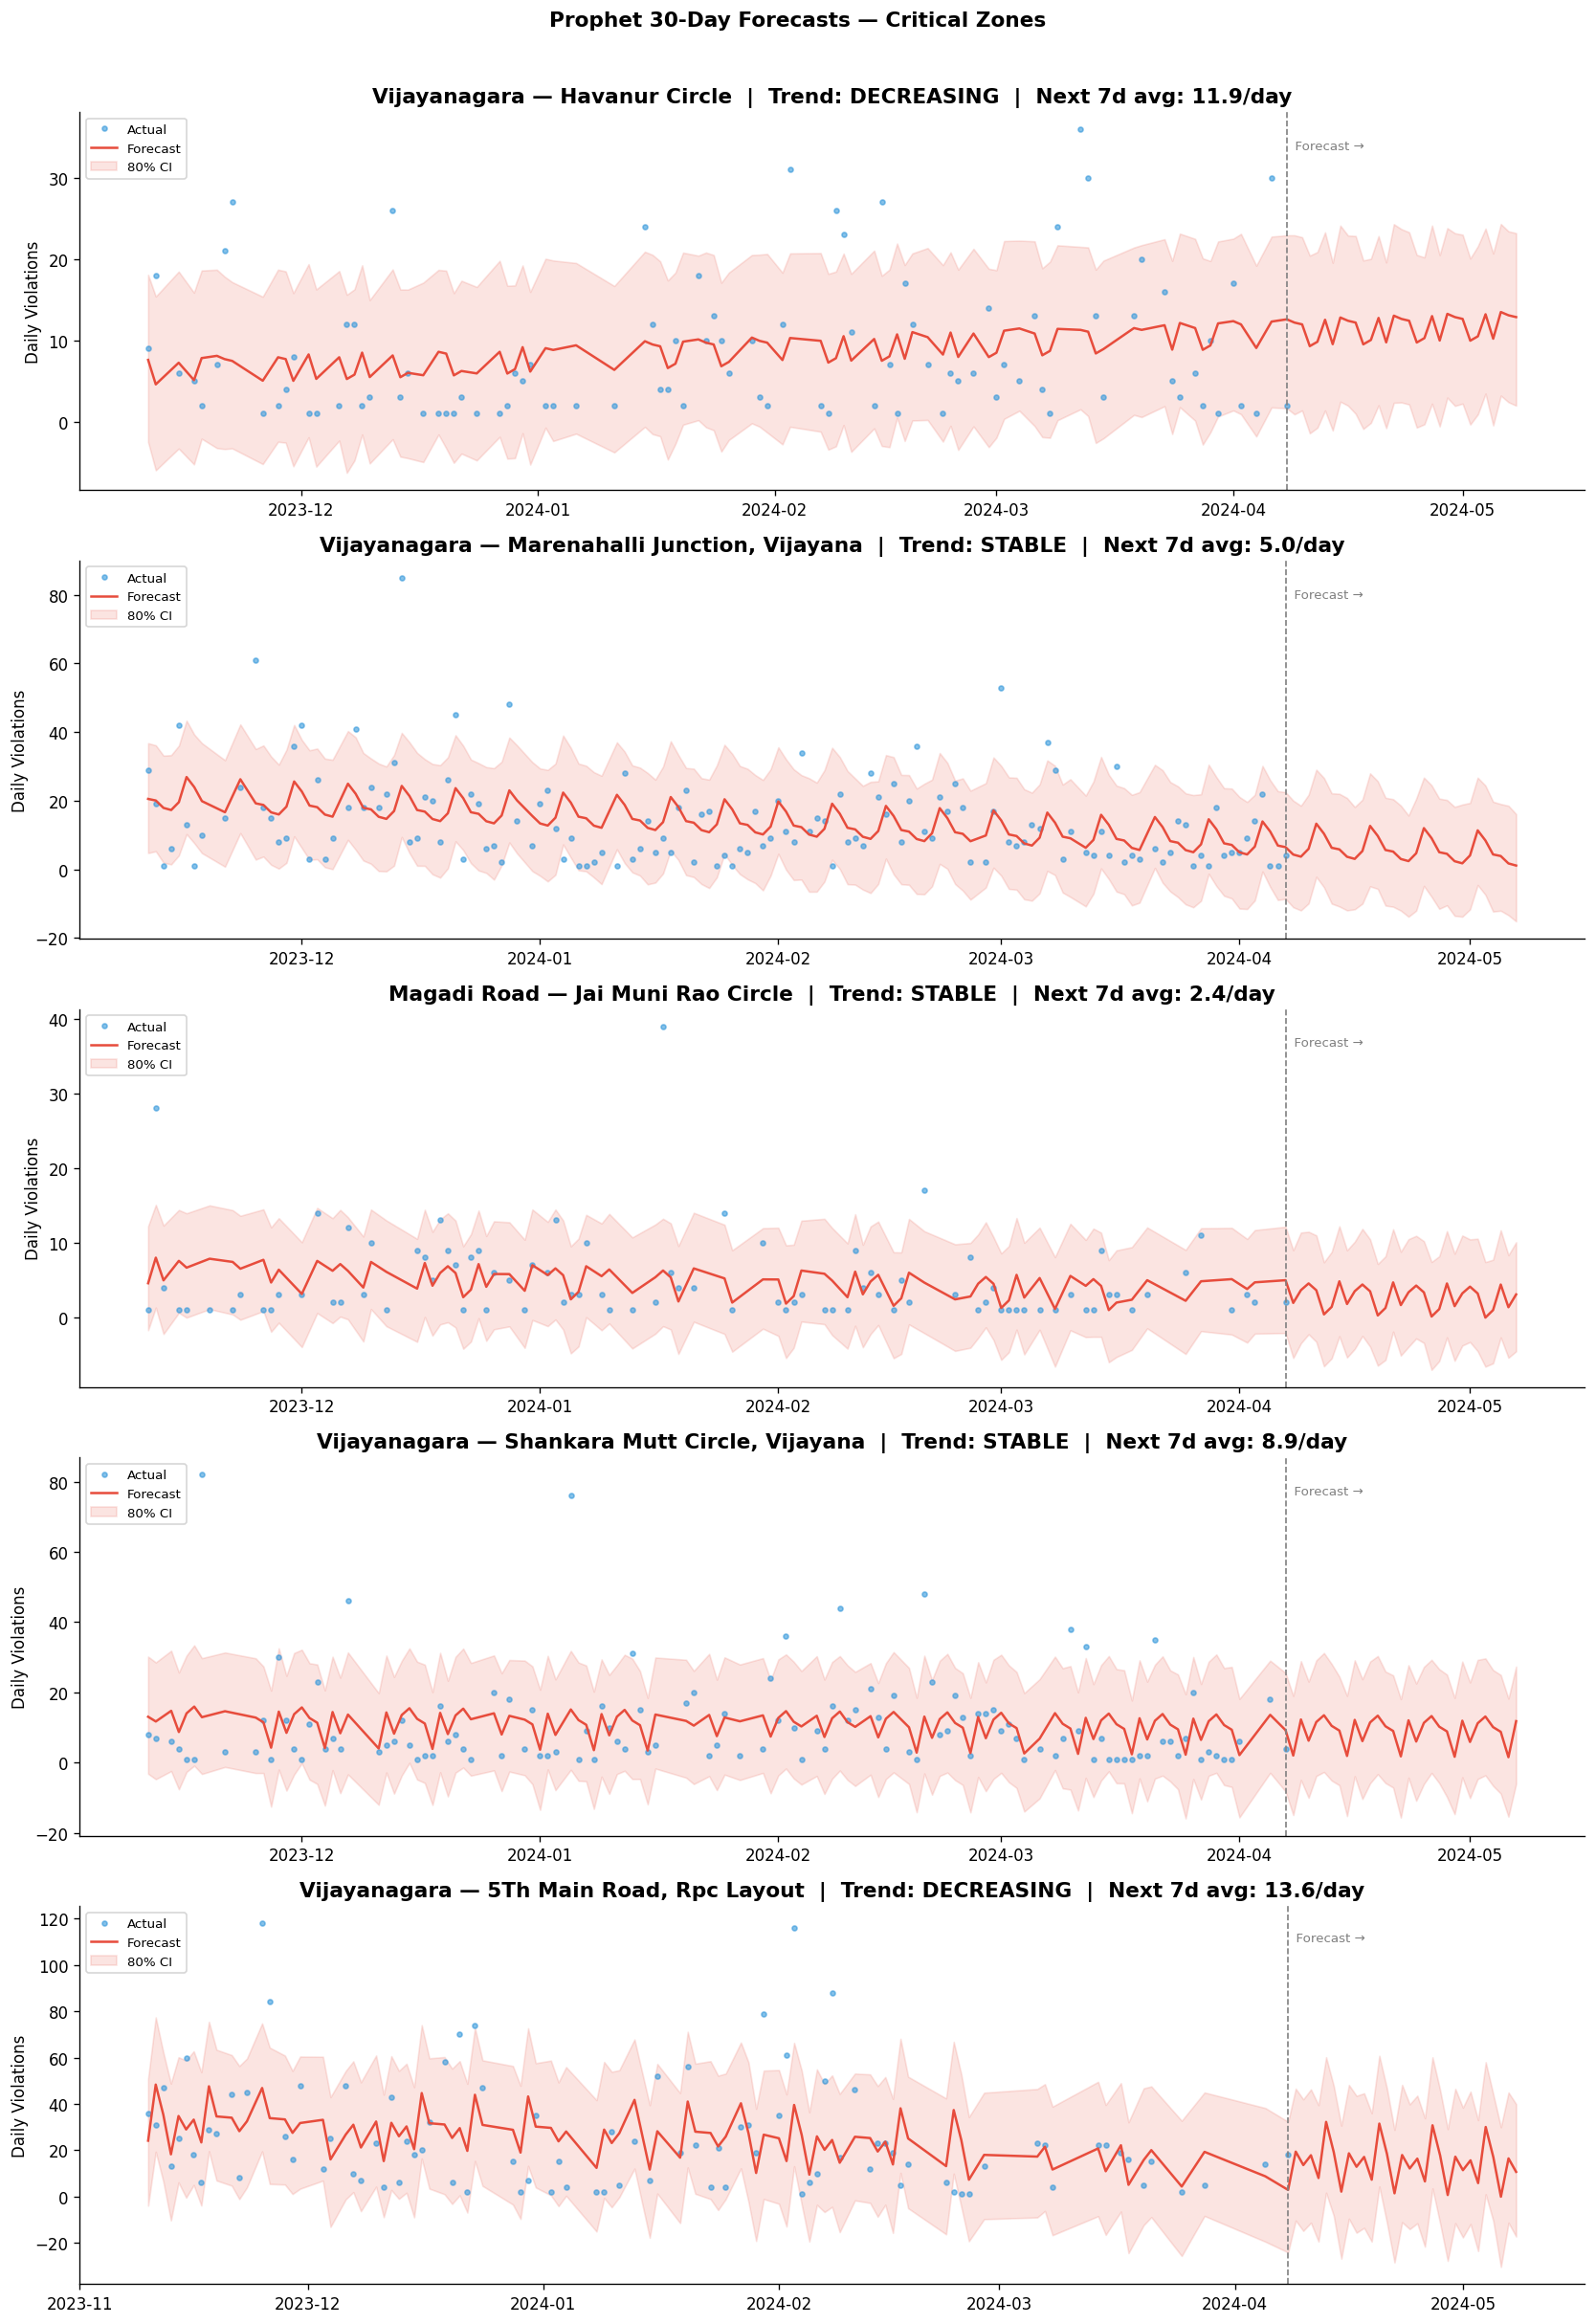

In [12]:
# Plot forecasts — top 5 critical zones only (others saved to file)
plot_ids = list(forecast_results.keys())[:5]
n = len(plot_ids)
if n > 0:
    fig, axes = plt.subplots(n, 1, figsize=(14, 4*n))
    if n == 1: axes = [axes]
    for ax, h3_id in zip(axes, plot_ids):
        res      = forecast_results[h3_id]
        daily    = res["daily"]
        forecast = res["forecast"]
        ax.plot(daily["ds"], daily["y"], "o", color="#3498db", ms=3, alpha=0.6, label="Actual")
        ax.plot(forecast["ds"], forecast["yhat"], "-", color="#e74c3c", lw=1.5, label="Forecast")
        ax.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"],
                        alpha=0.15, color="#e74c3c", label="80% CI")
        split = daily["ds"].max()
        ax.axvline(split, color="gray", ls="--", lw=1)
        ax.text(split, ax.get_ylim()[1]*0.88, "  Forecast →", fontsize=8, color="gray")
        ax.set_title(f"{res['label']}  |  Trend: {res['prophet_trend'].upper()}  "
                     f"|  Next 7d avg: {res['next7_avg']:.1f}/day")
        ax.set_ylabel("Daily Violations"); ax.legend(fontsize=8, loc="upper left")
    plt.suptitle("Prophet 30-Day Forecasts — Critical Zones",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(PROCESSED/"temporal_04_prophet_forecasts.png", bbox_inches="tight", dpi=120)
    plt.show()


In [13]:
# Trend summary across ALL profiled zones
print("=" * 65)
print("FULL-CITY TREND SUMMARY")
print("=" * 65)
for tier in ["Critical","High","Medium","Low","Very Low"]:
    tier_zones = zone_profile_df[zone_profile_df["priority_tier"]==tier]
    inc = (tier_zones["trend"]=="increasing").sum()
    sta = (tier_zones["trend"]=="stable").sum()
    dec = (tier_zones["trend"]=="decreasing").sum()
    print(f"  {tier:10s}: {len(tier_zones):4d} zones  |  "
          f"📈 {inc}  ➡️ {sta}  📉 {dec}")

print()
print("Top 5 INCREASING zones (across all tiers):")
inc_zones = zone_profile_df[zone_profile_df["trend"]=="increasing"].nlargest(5,"ensemble_score")
print(inc_zones[["zone_label","priority_tier","ensemble_score","surge_pct","recent_count"]].to_string(index=False))


FULL-CITY TREND SUMMARY
  Critical  :    2 zones  |  📈 2  ➡️ 0  📉 0
  High      :   50 zones  |  📈 30  ➡️ 4  📉 16
  Medium    :  139 zones  |  📈 32  ➡️ 71  📉 36
  Low       :    3 zones  |  📈 0  ➡️ 3  📉 0
  Very Low  :  570 zones  |  📈 53  ➡️ 343  📉 174

Top 5 INCREASING zones (across all tiers):
                                 zone_label priority_tier  ensemble_score  surge_pct  recent_count
                  Upparpet — Elite Junction      Critical       90.826864       59.6        2202.0
Shivajinagar — Safina Plaza Junction (8861)      Critical       85.072219       80.7        1653.0
   Upparpet — Sagar Theatre Junction (8860)          High       79.361419       11.8         982.0
   Upparpet — Sagar Theatre Junction (8860)          High       75.760048       71.9         925.0
        Malleshwaram — Modi Bridge Junction          High       74.329496       24.7         711.0


## 7. Stratified Patrol Scheduler

Three mission slots per time period:

| Slot | Mission | Logic |
|------|---------|-------|
| 🔴 Firefighter | #1 Critical zone at this hour | Top by time-adjusted score, any tier |
| 🟡 Preventative | Best Medium/Low zone trending up | Skip + message if none qualify |
| 🔵 Wildcard | Highest surge zone (≥20 recent, >10% surge) | Any tier, surprise element |

Time-boost multiplier raised to **3.0** (was 1.4) so the queue visibly re-sorts as you slide through hours.


In [14]:
# Pre-deserialise hourly/daily counts once for speed
print("Pre-deserialising hourly/daily counts for scheduler...")
parsed_profiles = []
for _, row in tqdm(zone_profile_df.iterrows(), total=len(zone_profile_df)):
    hc = json.loads(row["hourly_counts"]) if isinstance(row["hourly_counts"], str) else row["hourly_counts"]
    dc = json.loads(row["daily_counts"])  if isinstance(row["daily_counts"],  str) else row["daily_counts"]
    tv = json.loads(row["top_violations"]) if isinstance(row["top_violations"], str) else row["top_violations"]
    tveh = json.loads(row["top_vehicles"]) if isinstance(row["top_vehicles"], str) else row["top_vehicles"]
    parsed_profiles.append({
        **row.to_dict(),
        "hourly_counts_dict": hc,
        "daily_counts_dict" : dc,
        "top_violations_list": tv,
        "top_vehicles_list"  : tveh,
    })

parsed_df = pd.DataFrame(parsed_profiles)
print(f"✅ Ready. {len(parsed_df):,} zones loaded.")


Pre-deserialising hourly/daily counts for scheduler...


100%|██████████| 764/764 [00:00<00:00, 14541.15it/s]

✅ Ready. 764 zones loaded.


In [20]:
def compute_time_adjusted_score(row, hour, day_name, boost=3.0):
    """
    Compute time-adjusted score with aggressive boost.
    boost=3.0 means a zone at its peak hour scores 4x its base score.
    """
    base     = row["ensemble_score"]
    hc       = row["hourly_counts_dict"]
    dc       = row["daily_counts_dict"]
    total_h  = max(sum(hc.values()), 1)
    total_d  = max(sum(dc.values()), 1)
    time_rel = hc.get(hour, hc.get(str(hour), 0)) / total_h
    day_rel  = dc.get(day_name, dc.get(str(day_name), 0)) / total_d
    return base * (1 + boost * time_rel + 0.5 * day_rel)


def get_stratified_missions(hour, day_name):
    """
    Return the three stratified patrol missions for a given time.
    Returns dict with keys: firefighter, preventative, wildcard.
    Each value is a dict of zone info, or None with a message.
    """
    # Score all zones
    scores = []
    for _, row in parsed_df.iterrows():
        adj = compute_time_adjusted_score(row, hour, day_name)
        scores.append({
            "h3_id"          : row["h3_id"],
            "zone_label"     : row["zone_label"],
            "police_station" : row["police_station"],
            "top_junction"   : row["top_junction"],
            "priority_tier"  : row["priority_tier"],
            "base_score"     : round(row["ensemble_score"], 1),
            "adj_score"      : round(adj, 1),
            "peak_hour"      : row["peak_hour"],
            "peak_day"       : row["peak_day"],
            "top_violations" : row["top_violations_list"],
            "top_vehicles"   : row["top_vehicles_list"],
            "trend"          : row["trend"],
            "surge_pct"      : row["surge_pct"],
            "recent_count"   : row["recent_count"],
            "wildcard_eligible": row["wildcard_eligible"],
            "violation_count": row["violation_count"],
            "lat"            : row["lat"],
            "lon"            : row["lon"],
        })

    score_df = pd.DataFrame(scores).sort_values("adj_score", ascending=False)

    # 🔴 FIREFIGHTER: #1 zone by time-adjusted score (any tier)
    firefighter = score_df.iloc[0].to_dict() if len(score_df) > 0 else None

    # 🟡 PREVENTATIVE: highest Medium/Low zone with INCREASING trend
    prev_candidates = score_df[
        (score_df["priority_tier"].isin(["Medium","Low","Very Low"])) &
        (score_df["trend"] == "increasing")
    ]
    if len(prev_candidates) > 0:
        preventative = prev_candidates.iloc[0].to_dict()
        preventative["message"] = None
    else:
        preventative = None  # Will show message in dashboard

    # 🔵 WILDCARD: highest surge zone regardless of tier
    wild_candidates = score_df[score_df["wildcard_eligible"] == 1].sort_values(
        "surge_pct", ascending=False)
    wildcard = wild_candidates.iloc[0].to_dict() if len(wild_candidates) > 0 else None

    return {"firefighter": firefighter, "preventative": preventative, "wildcard": wildcard}


def get_full_ranked_queue(hour, day_name, top_n=50):
    """Full ranked queue for enforcement table — all zones."""    
    rows = []
    for _, row in parsed_df.iterrows():
        adj = compute_time_adjusted_score(row, hour, day_name)
        rows.append({
            "Zone"           : row["zone_label"],
            "Station"        : row["police_station"],
            "Junction"       : row["top_junction"],
            "Tier"           : row["priority_tier"],
            "Adj Score"      : round(adj, 1),
            "Base Score"     : round(row["ensemble_score"], 1),
            "Peak Hour"      : f"{row['peak_hour']}:00",
            "Peak Day"       : row["peak_day"],
            "Trend"          : row["trend"],
            "Surge %"        : row["surge_pct"],
            "Top Offense"    : (", ".join(row["top_violations_list"][:1])
                                if row["top_violations_list"] else "—"),
            "Top Vehicle"    : (", ".join(row["top_vehicles_list"][:1])
                                if row["top_vehicles_list"] else "—"),
            "lat"            : row["lat"],
            "lon"            : row["lon"],
        })
    return (pd.DataFrame(rows)
              .sort_values("Adj Score", ascending=False)
              .head(top_n)
              .reset_index(drop=True))


print("✅ Scheduler functions ready.")


✅ Scheduler functions ready.


In [21]:
# Demo: stratified missions right now
import datetime
now_ist      = datetime.datetime.now(datetime.timezone(datetime.timedelta(hours=5, minutes=30)))
current_hour = now_ist.hour
current_day  = now_ist.strftime("%A")

print(f"Current IST: {now_ist.strftime('%H:%M')} on {current_day}")
print()

missions = get_stratified_missions(current_hour, current_day)

def print_mission(icon, name, m):
    print(f"{icon} {name.upper()}")
    if m is None:
        print(f"   ⚪ No qualifying zone — all Medium/Low/Very Low zones are stable or decreasing.")
    else:
        print(f"   Zone    : {m['zone_label']}")
        print(f"   Tier    : {m['priority_tier']}  |  Adj Score: {m['adj_score']:.1f}  |  Base: {m['base_score']:.1f}")
        print(f"   Peak    : {m['peak_hour']}:00 on {m['peak_day']}")
        print(f"   Offenses: {', '.join(m['top_violations'][:2]) if m['top_violations'] else 'N/A'}")
        if name == "wildcard":
            print(f"   Surge   : +{m['surge_pct']:.0f}% ({int(m['recent_count'])} violations in last 14 days)")
        elif name == "preventative":
            print(f"   Trend   : {m['trend'].upper()} (+{m['surge_pct']:.0f}%)")
    print()

print_mission("🔴","firefighter",  missions["firefighter"])
print_mission("🟡","preventative", missions["preventative"])
print_mission("🔵","wildcard",     missions["wildcard"])


Current IST: 16:24 on Wednesday

🔴 FIREFIGHTER
   Zone    : Upparpet — Elite Junction
   Tier    : Critical  |  Adj Score: 95.9  |  Base: 90.8
   Peak    : 9:00 on Saturday
   Offenses: WRONG PARKING, NO PARKING

🟡 PREVENTATIVE
   Zone    : Ashok Nagar — Nanjappa Circle (8861)
   Tier    : Medium  |  Adj Score: 66.4  |  Base: 59.5
   Peak    : 4:00 on Thursday
   Offenses: NO PARKING, WRONG PARKING
   Trend   : INCREASING (+12%)

🔵 WILDCARD
   Zone    : Hennuru — Doddagubbi Road
   Tier    : Very Low  |  Adj Score: 3.9  |  Base: 3.8
   Peak    : 11:00 on Sunday
   Offenses: NO PARKING, WRONG PARKING
   Surge   : +5800% (59 violations in last 14 days)



In [22]:
# Full ranked queue demo
queue = get_full_ranked_queue(current_hour, current_day, top_n=15)
print(f"TOP 15 ZONES AT {current_hour:02d}:00 on {current_day}:")
print(queue[["Zone","Tier","Adj Score","Base Score","Trend","Surge %","Top Offense"]].to_string())


TOP 15 ZONES AT 16:00 on Wednesday:
                                                      Zone      Tier  Adj Score  Base Score       Trend  Surge %                          Top Offense
0                                Upparpet — Elite Junction  Critical       95.9        90.8  increasing     59.6                        WRONG PARKING
1              Shivajinagar — Safina Plaza Junction (8861)  Critical       89.1        85.1  increasing     80.7                        WRONG PARKING
2                         Hennuru — Manyata Residency Road    Medium       87.1        58.0      stable      0.0                           NO PARKING
3                                Bellandur — 1St Main Road    Medium       86.2        57.5      stable      0.0                        WRONG PARKING
4   Devanahalli Airport — Terminal 1 Departure Road (8860)    Medium       84.8        56.5      stable      0.0  PARKING IN A MAIN ROADWRONG PARKING
5                               Chikkajala — Road Number 1    Me

## 8. Full-Week Stratified Patrol Calendar

In [23]:
slots = [(6,"06–09"),(9,"09–12"),(12,"12–15"),(15,"15–18"),(18,"18–21"),(21,"21–24")]
days  = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

print("Building full-week stratified patrol calendar...")
cal_rows = []

for day in tqdm(days, desc="Days"):
    for slot_hour, slot_label in slots:
        missions = get_stratified_missions(slot_hour, day)

        for mission_type, m in missions.items():
            if m is None:
                cal_rows.append({
                    "day":day, "time_slot":slot_label,
                    "mission":mission_type, "zone_label":"— No qualifying zone —",
                    "station":"—", "junction":"—", "tier":"—",
                    "adj_score":0, "surge_pct":0, "trend":"—",
                    "lat":12.97, "lon":77.59,
                })
            else:
                cal_rows.append({
                    "day":day, "time_slot":slot_label,
                    "mission":mission_type,
                    "zone_label":m["zone_label"],
                    "station":m["police_station"],
                    "junction":m["top_junction"],
                    "tier":m["priority_tier"],
                    "adj_score":m["adj_score"],
                    "surge_pct":m["surge_pct"],
                    "trend":m["trend"],
                    "lat":m["lat"],
                    "lon":m["lon"],
                })

calendar_df = pd.DataFrame(cal_rows)
print(f"✅ Calendar: {len(calendar_df)} rows ({len(days)*len(slots)*3} mission assignments)")
print(calendar_df.groupby("mission")["zone_label"].apply(lambda x: (x!="— No qualifying zone —").sum()).rename("assignments"))


Building full-week stratified patrol calendar...


Days: 100%|██████████| 7/7 [00:03<00:00,  1.97it/s]

✅ Calendar: 126 rows (126 mission assignments)
mission
firefighter     42
preventative    42
wildcard        42
Name: assignments, dtype: int64


## 9. GenAI Assistant — Gemini 2.5 Flash

AI context now includes:
- Top 20 zones (Critical + High) with full stats
- Top 10 Medium zones
- Top 10 Low/Very Low zones
- Current stratified mission recommendations

This means the assistant can answer questions about mid/low zones too.


In [24]:
import google.generativeai as genai

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY","")
if not GOOGLE_API_KEY:
    print("⚠️  GOOGLE_API_KEY not in .env — GenAI cells will be skipped.")
    GENAI_AVAILABLE = False
else:
    genai.configure(api_key=GOOGLE_API_KEY)
    gemini_flash = genai.GenerativeModel("gemini-2.5-flash")
    gemini_pro   = genai.GenerativeModel("gemini-2.5-pro")
    GENAI_AVAILABLE = True
    print("✅ Gemini 2.5 Flash + Pro connected.")


✅ Gemini 2.5 Flash + Pro connected.


In [27]:
SYSTEM_PROMPT = """You are ParkSentinel, an AI assistant for Bengaluru Traffic Police.
You help traffic inspectors understand parking violation patterns across ALL priority levels
— from Critical hotspots to emerging Low-risk zones.

Rules:
- ALWAYS cite specific numbers from the data context. Never invent figures.
- Cover zones at ALL priority tiers when relevant, not just Critical ones.
- If asked about a zone not in the context, say so explicitly.
- Answers must be operational: tell the inspector WHAT to do and WHEN.
- For emerging/low zones, explain why they deserve attention now.
- Keep answers under 250 words unless a detailed breakdown is requested.
- Use plain English — inspectors are not data scientists.
"""


def build_full_context(hour=None, day_name=None):
    """
    Build a rich context block covering ALL tiers.
    Stratified mission context is injected if hour+day are provided.
    """
    lines = ["=== BENGALURU PARKING VIOLATION INTELLIGENCE — FULL CITY DATA ===\n"]

    # Current missions (if time given)
    if hour is not None and day_name is not None:
        missions = get_stratified_missions(hour, day_name)
        lines.append(f"== CURRENT PATROL MISSIONS ({hour:02d}:00 on {day_name}) ==")
        ff = missions["firefighter"]
        pv = missions["preventative"]
        wc = missions["wildcard"]
        if ff: lines.append(f"🔴 FIREFIGHTER: {ff['zone_label']} (Score:{ff['adj_score']:.0f})")
        if pv: lines.append(f"🟡 PREVENTATIVE: {pv['zone_label']} (Trend:{pv['trend']}, Surge:{pv['surge_pct']:.0f}%)")
        else:  lines.append("🟡 PREVENTATIVE: No qualifying zone (all mid/low zones stable)")
        if wc: lines.append(f"🔵 WILDCARD: {wc['zone_label']} (Surge:{wc['surge_pct']:.0f}%, Recent:{int(wc['recent_count'])})")
        lines.append("")

    # Build tier sections
    tier_configs = [
        ("Critical", 20, "Severe congestion risk — immediate enforcement priority"),
        ("High",     15, "Significant risk — should be in active patrol rotation"),
        ("Medium",   10, "Moderate risk — preventative patrol target"),
        ("Low",       8, "Low risk — monitor for upward trends"),
        ("Very Low",  5, "Minimal current risk — early-warning watch list"),
    ]

    for tier, limit, description in tier_configs:
        tier_zones = zone_profile_df[zone_profile_df["priority_tier"]==tier].nlargest(limit,"ensemble_score")
        if len(tier_zones) == 0: continue
        lines.append(f"\n== {tier.upper()} ZONES ({len(zone_profile_df[zone_profile_df['priority_tier']==tier])} total, showing top {len(tier_zones)}) ==")
        lines.append(f"Description: {description}")

        for _, row in tier_zones.iterrows():
            tv = json.loads(row["top_violations"]) if isinstance(row["top_violations"],str) else row["top_violations"]
            tveh = json.loads(row["top_vehicles"]) if isinstance(row["top_vehicles"],str) else row["top_vehicles"]
            lines.append(
                f"  • {row['zone_label']} | Score:{row['ensemble_score']:.0f} | "
                f"Violations:{row['violation_count']:,} | Peak:{row['peak_hour']}:00 {row['peak_day']} | "
                f"Trend:{row['trend']} | Surge:{row['surge_pct']:+.0f}% | "
                f"Offenses:{', '.join(tv[:2]) if tv else 'N/A'} | "
                f"Vehicles:{', '.join(tveh[:2]) if tveh else 'N/A'}"
            )

    return "\n".join(lines)


def ask(question, use_pro=False, hour=None, day_name=None):
    """Ask ParkSentinel with full-city context."""    
    if not GENAI_AVAILABLE:
        return "[GenAI unavailable — add GOOGLE_API_KEY to .env]"
    context = build_full_context(hour=hour, day_name=day_name)
    prompt  = f"{SYSTEM_PROMPT}\n\n{context}\n\nInspector: {question}\n\nParkSentinel:"
    model   = gemini_pro if use_pro else gemini_flash
    return model.generate_content(prompt).text

print("✅ Full-city context builder ready.")
print(f"   Context covers: Critical(top20) + High(top15) + Medium(top10) + Low(top8) + VeryLow(top5)")


✅ Full-city context builder ready.
   Context covers: Critical(top20) + High(top15) + Medium(top10) + Low(top8) + VeryLow(top5)


In [28]:
# Demo Q&A — covering all tiers
if GENAI_AVAILABLE:
    demo_qs = [
        ("Which zone should I patrol RIGHT NOW?", current_hour, current_day),
        ("Are there any medium or low risk zones that are showing an increasing trend I should watch?", None, None),
        ("Give me the top 3 critical zones and contrast them with 2 emerging low-risk zones.", None, None),
        ("Which vehicle types are causing issues in the medium-risk zones?", None, None),
    ]
    for q, h, d in demo_qs:
        print(f"{'='*65}")
        print(f"Q: {q}")
        print(f"{'─'*65}")
        print(ask(q, hour=h, day_name=d))
        print()


Q: Which zone should I patrol RIGHT NOW?
─────────────────────────────────────────────────────────────────
Inspector, for immediate patrol *right now*, prioritize **Upparpet — Elite Junction**. This is a 'FIREFIGHTER' mission with a Score of 96 and is a Critical Zone experiencing a +60% surge, with 20,216 violations. Focus on 'WRONG PARKING' and 'NO PARKING' by scooters and cars.

Following that, address two other urgent missions:

1.  **Hennuru — Doddagubbi Road:** This 'WILDCARD' zone shows an alarming +5800% surge, with 59 recent violations. This massive surge indicates a rapidly escalating situation, requiring immediate intervention to prevent it from becoming a major hotspot.
2.  **Ashok Nagar — Nanjappa Circle (8861):** This 'PREVENTATIVE' mission, also a Medium Zone, has an increasing trend with 1,508 violations and a +12% surge. Your presence now can help curb this upward trend, especially for 'NO PARKING' and 'WRONG PARKING' by scooters and motorcycles.

Your immediate presenc

In [29]:
# Interactive cell
YOUR_QUESTION = "Which low-risk zones are trending upward and should I add them to my patrol route?"
if GENAI_AVAILABLE:
    print(f"Q: {YOUR_QUESTION}")
    print("─"*65)
    print(ask(YOUR_QUESTION, hour=current_hour, day_name=current_day))


Q: Which low-risk zones are trending upward and should I add them to my patrol route?
─────────────────────────────────────────────────────────────────
Inspector, to proactively address potential issues, you should add the following low-risk zones to your patrol route due to their significant upward trends:

1.  **J.P. Nagar — Delmia Circle:** Despite being a Low Zone (Score: 22) with 85 total violations, this area shows a substantial **+250% surge** in NO PARKING and WRONG PARKING offenses by cars and scooters. This sharp increase indicates it's an emerging concern. Initiate patrols, especially around its peak time of **3:00 PM on Wednesday**, to prevent further escalation.

2.  **Hal Old Airport — 60 Feet Main Road:** This Very Low Zone (Score: 19) with just 7 violations has an alarming **+400% surge** in WRONG PARKING. While the violation count is low, such a dramatic percentage increase warrants immediate attention to prevent it from becoming a bigger problem. Monitor this zone, pa

## 10. Save All Outputs

In [30]:
# 1. Full zone profiles (all zones, with zone_label)
zp_out = PROCESSED/"zone_profiles_day3.parquet"
zone_profile_df.to_parquet(zp_out, index=False)
print(f"✅ Zone profiles ({len(zone_profile_df):,} zones) → {zp_out}")

# 2. Patrol calendar
cal_out = PROCESSED/"patrol_calendar.parquet"
calendar_df.to_parquet(cal_out, index=False)
print(f"✅ Patrol calendar → {cal_out}")

# 3. Map layer (all violations with h3_id)
ps_col = "police_station_x" if "police_station_x" in df.columns else "police_station"
map_cols = ["id","h3_id","latitude","longitude","hour","day_name",
            "severity_score","impact_score","is_peak_hour","near_junction",
            "vehicle_type", ps_col, "created_ist"]
df_map = df[map_cols].copy()
df_map.rename(columns={ps_col:"police_station"}, inplace=True)
map_out = PROCESSED/"violations_with_h3.parquet"
df_map.to_parquet(map_out, index=False)
print(f"✅ Map layer ({len(df_map):,} rows) → {map_out}")

# 4. Hex_df with zone_label (used by map page)
hex_enriched_out = PROCESSED/"h3_priority_scores_enriched.parquet"
hex_df.to_parquet(hex_enriched_out, index=False)
print(f"✅ Enriched hex_df → {hex_enriched_out}")

# 5. Readable patrol schedule CSV
try:
    ff_df = calendar_df[calendar_df["mission"]=="firefighter"]
    pivot = ff_df.pivot_table(index="day", columns="time_slot",
                               values="zone_label", aggfunc="first")
    pivot.reindex(days).to_csv(PROCESSED/"patrol_schedule_readable.csv")
    print(f"✅ Readable schedule CSV → {PROCESSED/'patrol_schedule_readable.csv'}")
except Exception as e:
    print(f"⚠️ Schedule CSV skipped: {e}")

# Cleanup checkpoint (we're done)
if CHECKPOINT_PATH.exists():
    CHECKPOINT_PATH.unlink()
    print("🗑️  Checkpoint file removed (full run complete)")


✅ Zone profiles (764 zones) → D:\Coding Stuff\grid2\data\processed\zone_profiles_day3.parquet
✅ Patrol calendar → D:\Coding Stuff\grid2\data\processed\patrol_calendar.parquet
✅ Map layer (298,282 rows) → D:\Coding Stuff\grid2\data\processed\violations_with_h3.parquet
✅ Enriched hex_df → D:\Coding Stuff\grid2\data\processed\h3_priority_scores_enriched.parquet
✅ Readable schedule CSV → D:\Coding Stuff\grid2\data\processed\patrol_schedule_readable.csv
🗑️  Checkpoint file removed (full run complete)


In [31]:
print("""
✅  DAY 3 REVISED — COMPLETE
─────────────────────────────────────────────────────────────────
[x] ALL hex zones profiled (not just top 20)
[x] Unique zone_label: "Station — Junction/Road" for every zone
[x] Checkpoint saves every 100 zones (crash-safe)
[x] Surge calculation (14-day window, min 20 violations)
[x] Prophet forecasting on Critical + High zones only (hybrid)
[x] Full trend tracking: increasing / stable / decreasing per zone
[x] Aggressive time-boost (×3.0) for visible slider re-sorting
[x] Stratified Patrol Missions:
      🔴 Firefighter  — #1 zone by time-adjusted score
      🟡 Preventative — Best Medium/Low trending up (skip+msg if none)
      🔵 Wildcard     — Highest surge zone (≥20 violations, >10% surge)
[x] Full-week patrol calendar with all 3 mission types
[x] GenAI context covers ALL tiers: Critical → Very Low
[x] Stratified mission context injected into AI prompt
[x] All parquet files saved for Streamlit dashboard

READY FOR STREAMLIT DASHBOARD:
  → zone_profiles_day3.parquet     (all zones, zone_label column)
  → patrol_calendar.parquet        (stratified missions, full week)
  → violations_with_h3.parquet     (map layer)
  → h3_priority_scores_enriched.parquet (hex polygons + zone_label)
""")



✅  DAY 3 REVISED — COMPLETE
─────────────────────────────────────────────────────────────────
[x] ALL hex zones profiled (not just top 20)
[x] Unique zone_label: "Station — Junction/Road" for every zone
[x] Checkpoint saves every 100 zones (crash-safe)
[x] Surge calculation (14-day window, min 20 violations)
[x] Prophet forecasting on Critical + High zones only (hybrid)
[x] Full trend tracking: increasing / stable / decreasing per zone
[x] Aggressive time-boost (×3.0) for visible slider re-sorting
[x] Stratified Patrol Missions:
      🔴 Firefighter  — #1 zone by time-adjusted score
      🟡 Preventative — Best Medium/Low trending up (skip+msg if none)
      🔵 Wildcard     — Highest surge zone (≥20 violations, >10% surge)
[x] Full-week patrol calendar with all 3 mission types
[x] GenAI context covers ALL tiers: Critical → Very Low
[x] Stratified mission context injected into AI prompt
[x] All parquet files saved for Streamlit dashboard

READY FOR STREAMLIT DASHBOARD:
  → zone_profiles_d